In [1]:
import wfdb
from signal_utils import expand_to_12_leads

# Load the signal from data/staff_III/001c
record = wfdb.rdrecord('data/staff_III/data/test')
staff_signal = record.p_signal[:5000].T # type: ignore
staff_signal, signal_12ch_names = expand_to_12_leads(staff_signal)

staff_sampling_rate: int = record.fs # type: ignore
staff_channel_names = signal_12ch_names

staff_signal = {name: staff_signal[i] for i, name in enumerate(signal_12ch_names)}

print(f"Signal shape: {len(staff_signal)} channels, {len(staff_signal[signal_12ch_names[0]])} samples per channel")
print(f"Sampling rate: {staff_sampling_rate} Hz")
print(f"Number of channels: {len(staff_signal)}")
print(f"Channel names: {list(staff_signal.keys())}")


Signal shape: 12 channels, 5000 samples per channel
Sampling rate: 1000 Hz
Number of channels: 12
Channel names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF']


In [2]:
from delineators import CombinedDelineator

combined_delineator = CombinedDelineator(staff_channel_names)

cleaned_signal, comb_QRS_features = combined_delineator.delineate(staff_signal, staff_sampling_rate)
print(staff_channel_names)


['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF']


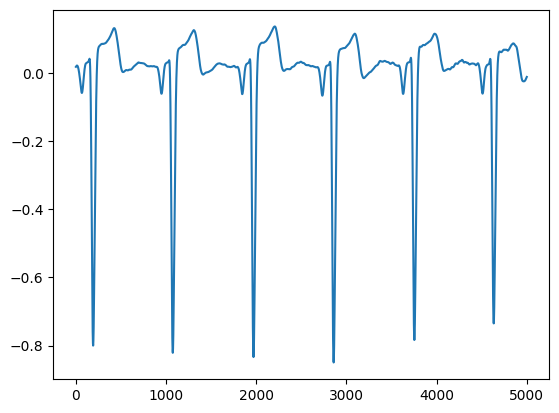

In [9]:
import matplotlib.pyplot as plt

plt.plot(cleaned_signal["V1"])

In [8]:
from ecg_features import compute_ecg_metrics

requested = [
# 1. Temporal / HR / HRV
    "heart_rate",
    "HR_min",
    "HR_max",
    "PR_interval",
    "QRS_duration",
    "QT_interval",
    "JT_interval",
    "QTc_bazett",
    "QTc_fridericia",
    "HRV_sdnn",
    "HRV_rmssd",
    # 2. Amplitudes
    "P_amplitude",
    "R_amplitude",
    "S_amplitude",
    "T_amplitude",
    # 3. ST / J-point
    "STE_J_point",
    "STE60",
    "STE80",
    # 6. Risk scores
    "Smith_3var"
]

metrics = df = compute_ecg_metrics(
    staff_signal,
    staff_sampling_rate, 
    comb_QRS_features, 
    requested_metrics=requested, 
    lead_name="V3"
)

In [9]:
metrics.to_csv("saves/staff_III_test_metrics.csv", index=False)
metrics

,lead,heart_rate,HR_min,HR_max,PR_interval,QRS_duration,QT_interval,JT_interval,QTc_bazett,QTc_fridericia,HRV_sdnn,HRV_rmssd,P_amplitude,R_amplitude,S_amplitude,T_amplitude,STE_J_point,STE60,STE80,Smith_3var
0,V3,67.552353,67.039106,68.259386,-751.4,123.0,458.833333,335.833333,486.854935,477.329239,6.610598,10.124228,-0.201,0.252292,-1.392292,-0.039375,-0.025992,0.070891,0.071208,28.72698
